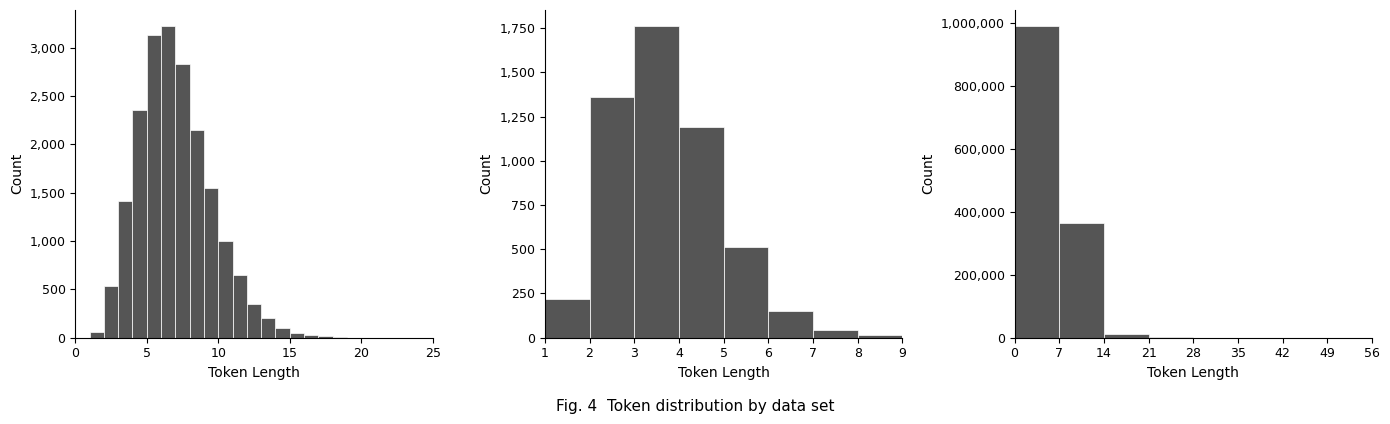

저장 완료: fig4_token_distribution.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── 1. 데이터 로드 ────────────────────────────────────────
wellness = pd.read_csv("cleaned_wellness.csv")
chatbot  = pd.read_csv("cleaned_chatbot.csv")
subject  = pd.read_csv("cleaned_subject.csv")

# ── 2. 토큰 길이 계산 (공백 기준) ─────────────────────────
def get_lengths(df, col="utterance"):
    return df[col].dropna().apply(lambda x: len(str(x).split())).tolist()

wellness_len = get_lengths(wellness)
chatbot_len  = get_lengths(chatbot)
subject_len  = get_lengths(subject)

# ── 3. subject용 bins 설정 (논문처럼 8개 막대) ───────────
# subject max=52이므로 0~52를 8구간으로 나눔 → 구간폭 약 6.5 → 7로 설정
# 0,7,14,21,28,35,42,49,56 → 8개 막대
subject_bins = [0, 7, 14, 21, 28, 35, 42, 49, 56]

# ── 4. 플롯 ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Wellness (왼쪽): 논문과 동일하게 x=0~25, 1칸씩 ---
axes[0].hist(wellness_len, bins=range(0, 27), color="#555555",
             edgecolor="white", linewidth=0.5)
axes[0].set_xlim(0, 25)
axes[0].set_xticks(range(0, 26, 5))

# --- Chatbot (가운데): x=1~9, 1칸씩 ---
axes[1].hist(chatbot_len, bins=range(1, 11), color="#555555",
             edgecolor="white", linewidth=0.5)
axes[1].set_xlim(1, 9)
axes[1].set_xticks(range(1, 10))

# --- Subject (오른쪽): 8개 막대 ---
axes[2].hist(subject_len, bins=subject_bins, color="#555555",
             edgecolor="white", linewidth=0.5)
axes[2].set_xlim(0, 56)
axes[2].set_xticks(subject_bins)

# --- 공통 스타일 ---
for ax in axes:
    ax.set_xlabel("Token Length", fontsize=10)
    ax.set_ylabel("Count",        fontsize=10)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=9)

fig.text(0.5, -0.04,
         "Fig. 4  Token distribution by data set",
         ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("fig4_token_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: fig4_token_distribution.png")

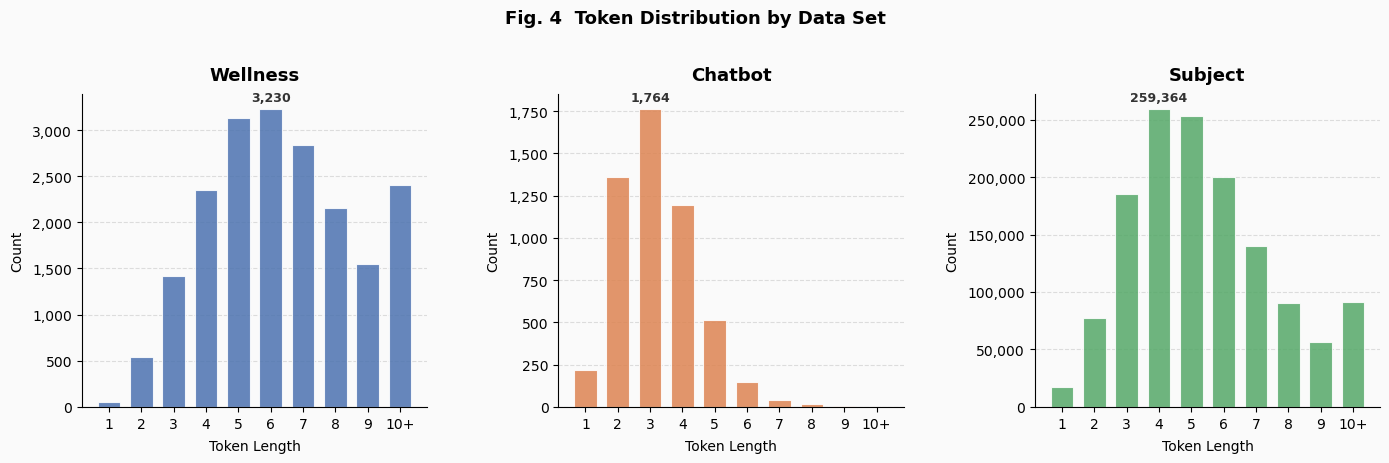

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

wellness = pd.read_csv("cleaned_wellness.csv")
chatbot  = pd.read_csv("cleaned_chatbot.csv")
subject  = pd.read_csv("cleaned_subject.csv")

def get_lengths(df):
    return df['utterance'].dropna().apply(lambda x: len(str(x).split())).tolist()

def clip_lengths(lengths, x_max=10):
    return [min(l, x_max) for l in lengths]

wl_c = clip_lengths(get_lengths(wellness))
cl_c = clip_lengths(get_lengths(chatbot))
sl_c = clip_lengths(get_lengths(subject))

bins = list(range(1, 12))  # [1, 2, ..., 11]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.patch.set_facecolor('#FAFAFA')

titles   = ['Wellness', 'Chatbot', 'Subject']
datasets = [wl_c, cl_c, sl_c]
colors   = ['#4C72B0', '#DD8452', '#55A868']

for ax, data, title, color in zip(axes, datasets, titles, colors):
    counts, _ = np.histogram(data, bins=bins)
    x_pos = np.arange(1, 11)

    bars = ax.bar(x_pos, counts, width=0.7, color=color,
                  edgecolor='white', linewidth=0.8, alpha=0.85)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(i) for i in range(1, 10)] + ['10+'], fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Token Length', fontsize=10, labelpad=6)
    ax.set_ylabel('Count', fontsize=10, labelpad=6)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')

    # 최대 막대에만 수치 표시
    max_idx = counts.argmax()
    ax.text(bars[max_idx].get_x() + bars[max_idx].get_width() / 2,
            counts[max_idx] + counts.max() * 0.015,
            f'{counts[max_idx]:,}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#333333')

fig.suptitle('Fig. 4  Token Distribution by Data Set',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(w_pad=3)
plt.savefig("fig4_token_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

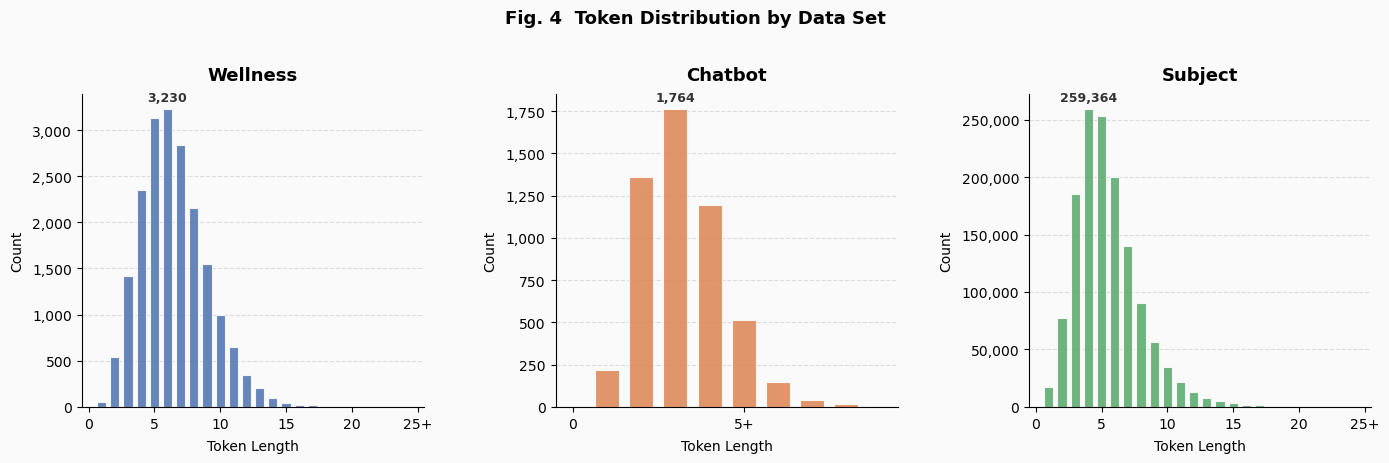

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

wellness = pd.read_csv("cleaned_wellness.csv")
chatbot  = pd.read_csv("cleaned_chatbot.csv")
subject  = pd.read_csv("cleaned_subject.csv")

def get_lengths(df):
    return df['utterance'].dropna().apply(lambda x: len(str(x).split())).tolist()

wl = get_lengths(wellness)
cl = get_lengths(chatbot)
sl = get_lengths(subject)

# wellness: 0~25+, chatbot: 0~9+, subject: 0~25+
configs = [
    (wl, 25, 'Wellness', '#4C72B0'),
    (cl,  9, 'Chatbot',  '#DD8452'),
    (sl, 25, 'Subject',  '#55A868'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.patch.set_facecolor('#FAFAFA')

for ax, (data, x_max, title, color) in zip(axes, configs):
    clipped   = [min(l, x_max) for l in data]
    bins      = list(range(0, x_max + 2))
    counts, _ = np.histogram(clipped, bins=bins)
    x_pos     = np.arange(0, x_max + 1)

    bars = ax.bar(x_pos, counts, width=0.7, color=color,
                  edgecolor='white', linewidth=0.8, alpha=0.85)

    # x축 눈금: 5 간격, 마지막은 '25+' or '9+'
    tick_positions = list(range(0, x_max + 1, 5))
    tick_labels    = [str(t) for t in tick_positions]
    tick_labels[-1] = f'{tick_positions[-1]}+'
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.set_xlim(-0.5, x_max + 0.5)

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Token Length', fontsize=10, labelpad=6)
    ax.set_ylabel('Count', fontsize=10, labelpad=6)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')

    # 최대 막대에만 수치 표시
    max_idx = counts.argmax()
    ax.text(bars[max_idx].get_x() + bars[max_idx].get_width() / 2,
            counts[max_idx] + counts.max() * 0.015,
            f'{counts[max_idx]:,}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#333333')

fig.suptitle('Fig. 4  Token Distribution by Data Set',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(w_pad=3)
plt.savefig("fig4_token_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

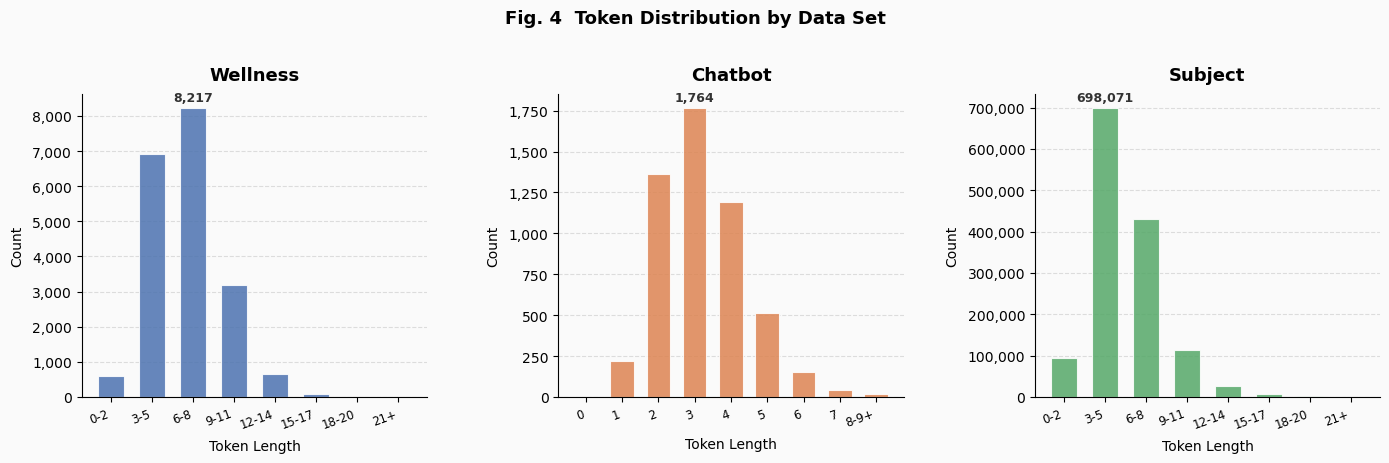

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

wellness = pd.read_csv("cleaned_wellness.csv")
chatbot  = pd.read_csv("cleaned_chatbot.csv")
subject  = pd.read_csv("cleaned_subject.csv")

def get_lengths(df):
    return df['utterance'].dropna().apply(lambda x: len(str(x).split())).tolist()

wl = get_lengths(wellness)
cl = get_lengths(chatbot)
sl = get_lengths(subject)

configs = [
    (wl, [0,3,6,9,12,15,18,21,26], ['0-2','3-5','6-8','9-11','12-14','15-17','18-20','21+'], 'Wellness', '#4C72B0'),
    (cl, [0,1,2,3,4,5,6,7,8,10],   ['0','1','2','3','4','5','6','7','8-9+'],                 'Chatbot',  '#DD8452'),
    (sl, [0,3,6,9,12,15,18,21,26], ['0-2','3-5','6-8','9-11','12-14','15-17','18-20','21+'], 'Subject',  '#55A868'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.patch.set_facecolor('#FAFAFA')

for ax, (data, bins, xlabels, title, color) in zip(axes, configs):
    counts, _ = np.histogram(data, bins=bins)
    x_pos = np.arange(len(counts))

    bars = ax.bar(x_pos, counts, width=0.65, color=color,
                  edgecolor='white', linewidth=0.8, alpha=0.85)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(xlabels, fontsize=8.5, rotation=20, ha='right')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Token Length', fontsize=10, labelpad=6)
    ax.set_ylabel('Count', fontsize=10, labelpad=6)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')

    # 최대 막대에만 수치 표시
    max_idx = counts.argmax()
    ax.text(bars[max_idx].get_x() + bars[max_idx].get_width() / 2,
            counts[max_idx] + counts.max() * 0.015,
            f'{counts[max_idx]:,}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#333333')

fig.suptitle('Fig. 4  Token Distribution by Data Set',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(w_pad=3)
plt.savefig("fig4_token_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

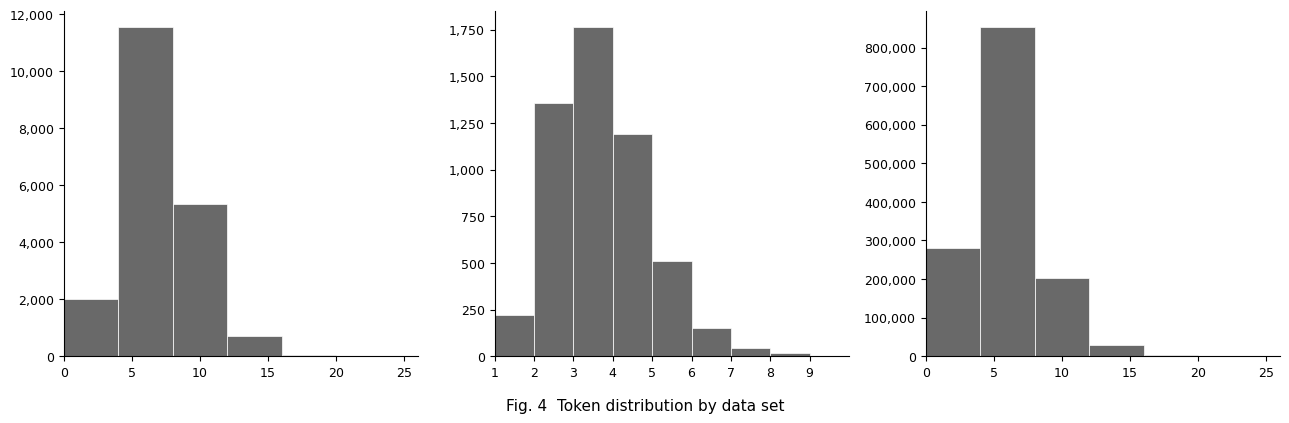

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

wellness = pd.read_csv("cleaned_wellness.csv")
chatbot  = pd.read_csv("cleaned_chatbot.csv")
subject  = pd.read_csv("cleaned_subject.csv")

def get_lengths(df):
    return df['utterance'].dropna().apply(lambda x: len(str(x).split())).tolist()

wl = get_lengths(wellness)
cl = get_lengths(chatbot)
sl = get_lengths(subject)

# wellness/subject: x눈금 5칸 간격, 막대 4칸마다
# chatbot:          x눈금 1칸 간격, 막대 1칸마다
configs = [
    (wl, [0,4,8,12,16,20,24,26], 'Wellness', [0,5,10,15,20,25]),
    (cl, [1,2,3,4,5,6,7,8,9,10], 'Chatbot',  [1,2,3,4,5,6,7,8,9]),
    (sl, [0,4,8,12,16,20,24,26], 'Subject',  [0,5,10,15,20,25]),
]

BAR_COLOR = '#696969'

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (data, bins, title, xticks) in zip(axes, configs):
    counts, edges = np.histogram(data, bins=bins)

    widths = np.diff(edges)
    ax.bar(edges[:-1], counts, width=widths, align='edge',
           color=BAR_COLOR, edgecolor='white', linewidth=0.5)

    ax.set_xticks(xticks)
    ax.set_xticklabels([str(t) for t in xticks], fontsize=9)
    ax.set_xlim(edges[0], edges[-1])

    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
    )
    ax.tick_params(axis='both', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.text(0.5, -0.04, 'Token distribution by data set',
         ha='center', fontsize=11)

plt.tight_layout()
plt.savefig("fig4_token_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

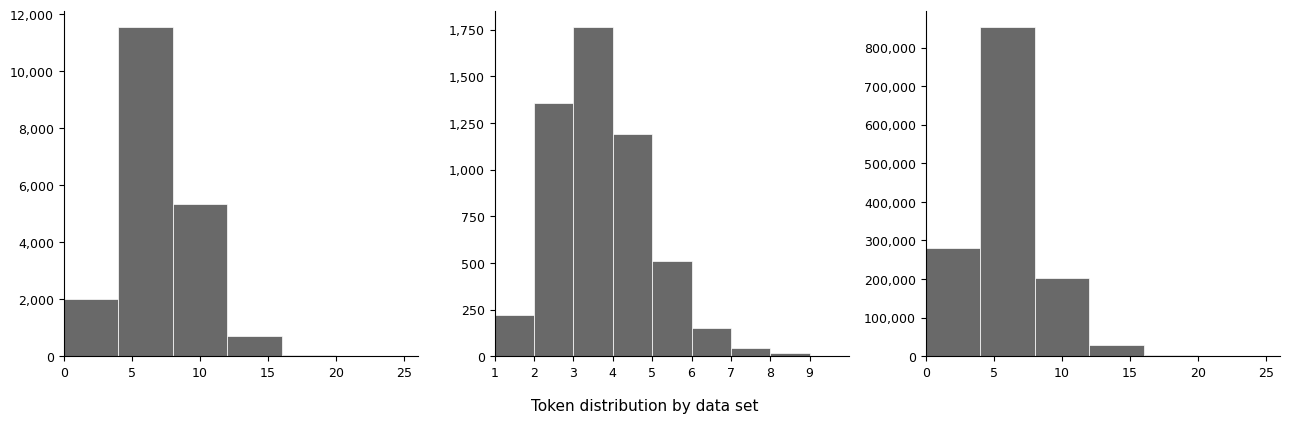

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

wellness = pd.read_csv("cleaned_wellness.csv")
chatbot  = pd.read_csv("cleaned_chatbot.csv")
subject  = pd.read_csv("cleaned_subject.csv")

def get_lengths(df):
    return df['utterance'].dropna().apply(lambda x: len(str(x).split())).tolist()

wl = get_lengths(wellness)
cl = get_lengths(chatbot)
sl = get_lengths(subject)

# wellness/subject: x눈금 5칸 간격, 막대 4칸마다
# chatbot:          x눈금 1칸 간격, 막대 1칸마다
configs = [
    (wl, [0,4,8,12,16,20,24,26], 'Wellness', [0,5,10,15,20,25]),
    (cl, [1,2,3,4,5,6,7,8,9,10], 'Chatbot',  [1,2,3,4,5,6,7,8,9]),
    (sl, [0,4,8,12,16,20,24,26], 'Subject',  [0,5,10,15,20,25]),
]

BAR_COLOR = '#696969'

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (data, bins, title, xticks) in zip(axes, configs):
    counts, edges = np.histogram(data, bins=bins)

    widths = np.diff(edges)
    ax.bar(edges[:-1], counts, width=widths, align='edge',
           color=BAR_COLOR, edgecolor='white', linewidth=0.5)

    ax.set_xticks(xticks)
    ax.set_xticklabels([str(t) for t in xticks], fontsize=9)
    ax.set_xlim(edges[0], edges[-1])

    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
    )
    ax.tick_params(axis='both', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.text(0.5, -0.04, 'Token distribution by data set',
         ha='center', fontsize=11)

plt.tight_layout()
plt.savefig("fig4_token_distribution.png", dpi=150, bbox_inches='tight')
plt.show()